Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔹 Dataset Overview:
                                       transactionId         country  \
0  4ab98aec7f52f8adde8773188e9090c3752ba37225d412...  United Kingdom   
1  192549cfbf4c643f0459b459fbe6501f6f79ac3be62076...         Finland   
2  b4b74a46da9f2ecac524c8e747e2bf48e0226e76cb6332...          Norway   
3  8a27e68e4baa1de9843b6a4a43a663dc638edb20692994...         Finland   
4  ce3c2d36d7379f4a2e5eb7dd1fbe85d107a951700396a8...  United Kingdom   

                                             EVModel  year  month  quarter  \
0                               Kia Soul, Kia e-Niro  2024     10        4   
1               Mercedes-Benz EQE, Mercedes-Benz EQS  2024      6        2   
2                                      Lexus UX 300e  2024     10        4   
3  MG MG4 Electric, MG MG5 Electric, MG Marvel R,...  2024      9        3   
4                          

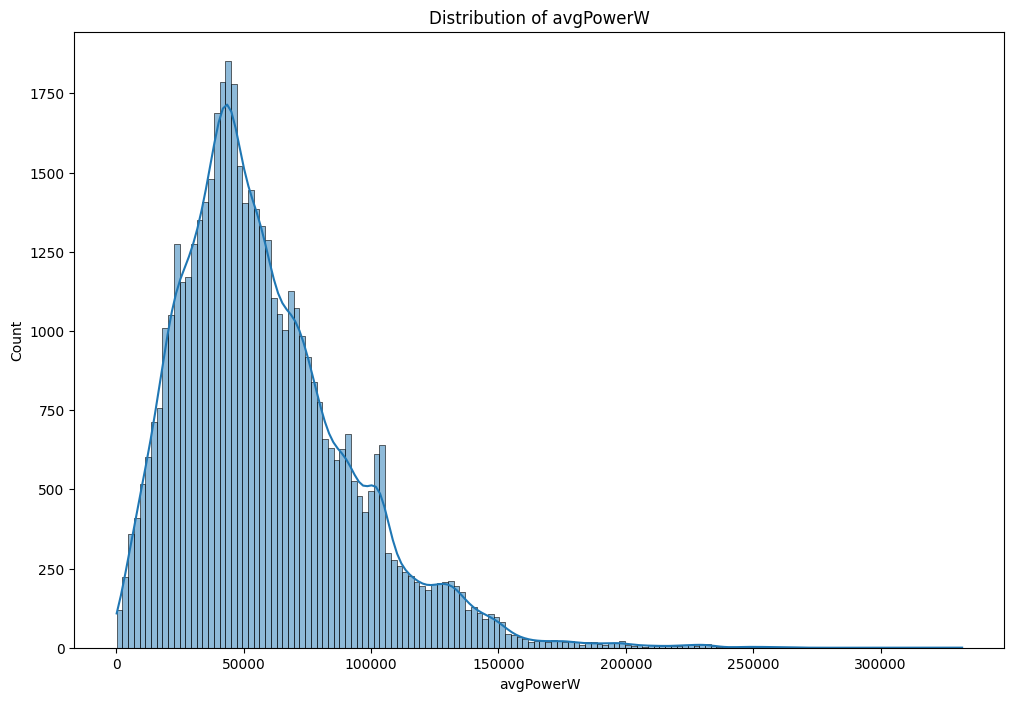

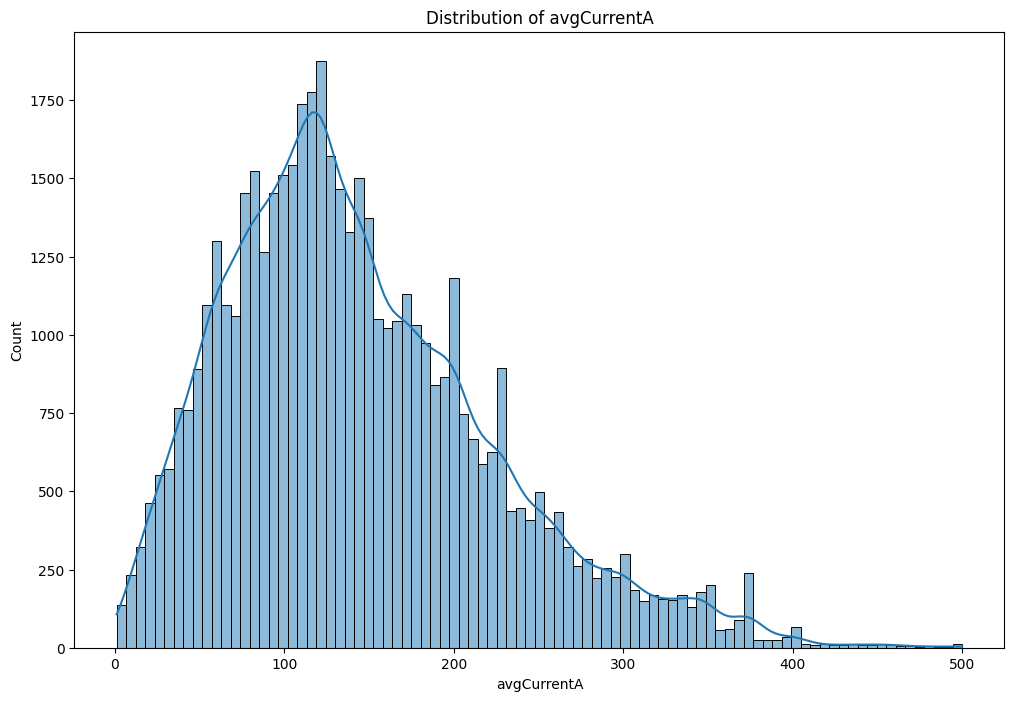

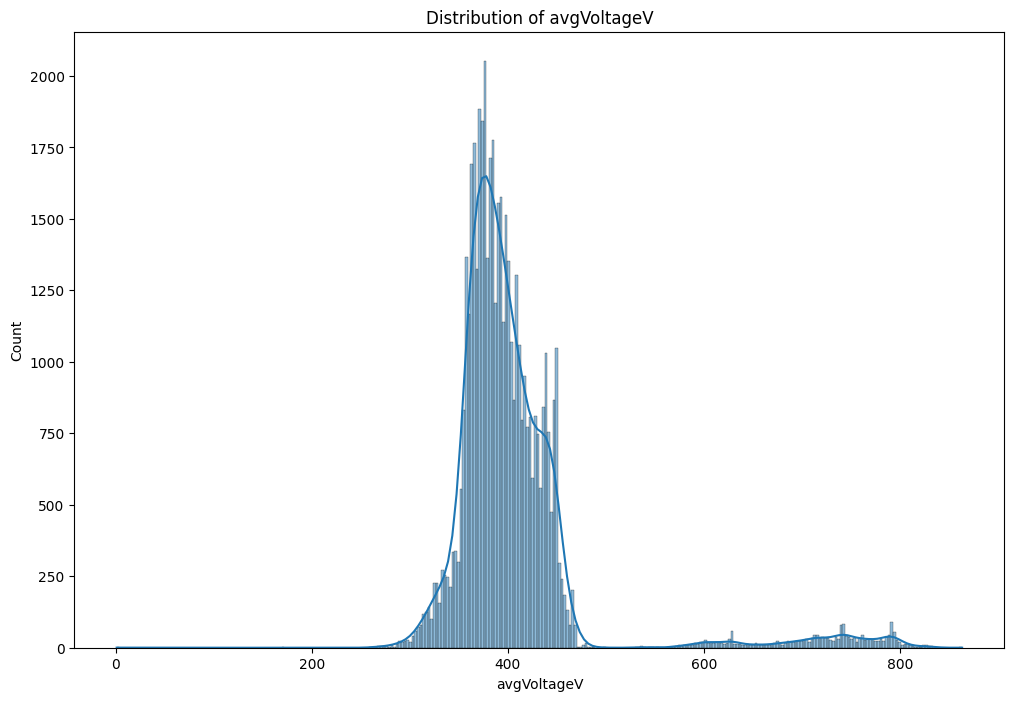

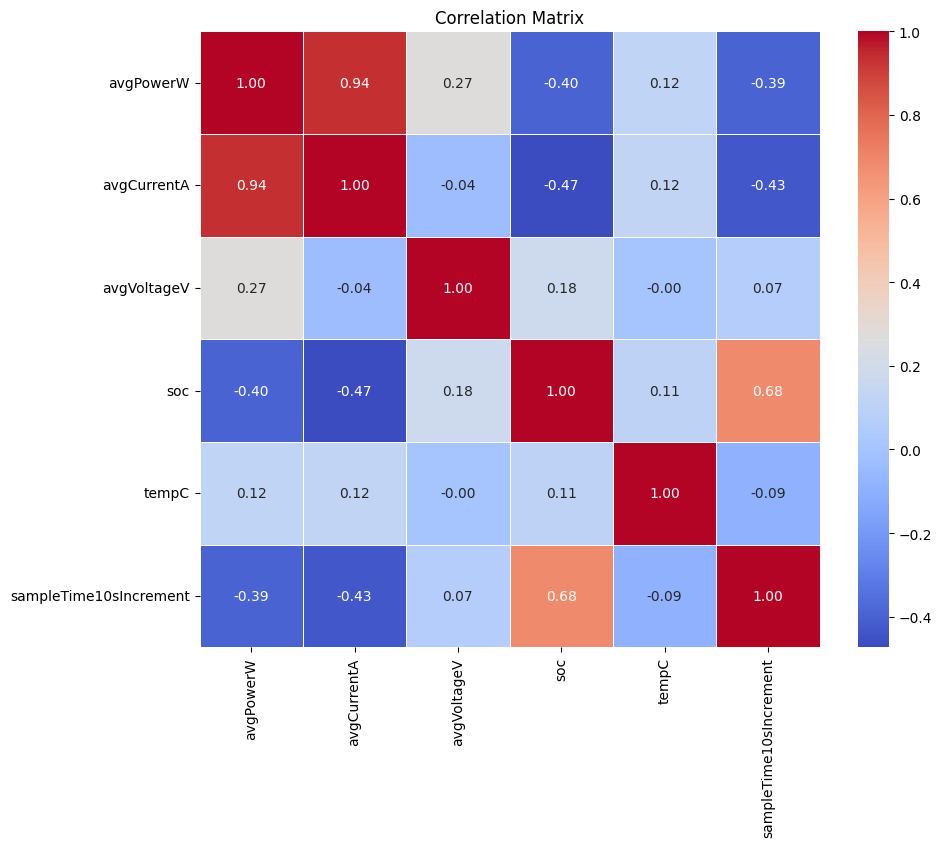

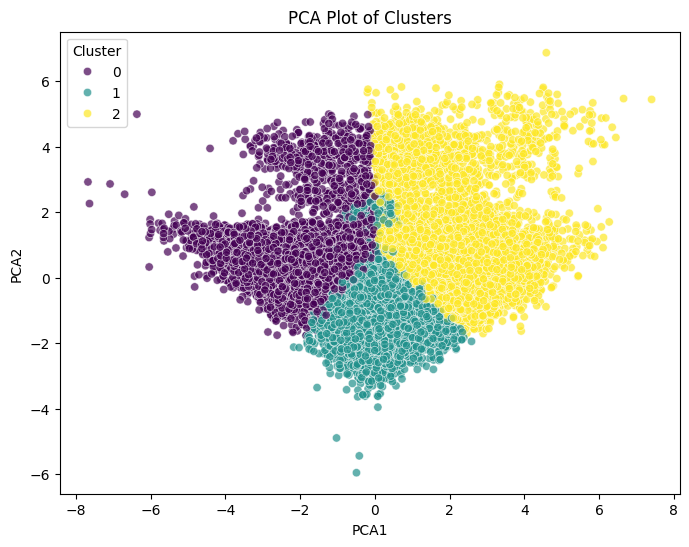


🔹 Silhouette Score: 0.229

🔹 Centroids of clusters:
   avgPowerW  avgCurrentA  avgVoltageV       soc     tempC  \
0  -0.693235    -0.760348     0.156331  1.048890  0.089493   
1  -0.276282    -0.202279    -0.303313 -0.472179 -0.280962   
2   1.342148     1.303011     0.310888 -0.536837  0.358082   

   sampleTime10sIncrement  
0                1.028877  
1               -0.472637  
2               -0.510708  

🔹 Assigned SoH Labels based on centroids:
   avgPowerW  avgCurrentA  avgVoltageV       soc     tempC  \
0  -0.693235    -0.760348     0.156331  1.048890  0.089493   
1  -0.276282    -0.202279    -0.303313 -0.472179 -0.280962   
2   1.342148     1.303011     0.310888 -0.536837  0.358082   

   sampleTime10sIncrement SoH_Label  
0                1.028877  Degraded  
1               -0.472637  Degraded  
2               -0.510708  Degraded  

🔹 Final DataFrame with SoH Labels:
   Cluster SoH_Label
0        0  Degraded
1        0  Degraded
2        1  Degraded
3        1  Degraded
4

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from google.colab import drive

# --- STEP 1: Mount Google Drive ---
drive.mount('/content/drive')

# --- STEP 2: Load Data ---
file_path = '/content/drive/MyDrive/cryto_research/50Ksample.csv'
df = pd.read_csv(file_path)

# --- STEP 3: Exploratory Data Analysis (EDA) ---

# 3.1: Overview of the dataset
print("\n🔹 Dataset Overview:")
print(df.head())

# 3.2: Summary statistics
print("\n🔹 Summary Statistics:")
print(df.describe())

# 3.3: Check for missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())

# 3.4: Visualizing distributions of key features
plt.figure(figsize=(12, 8))
sns.histplot(df['avgPowerW'], kde=True)
plt.title('Distribution of avgPowerW')
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df['avgCurrentA'], kde=True)
plt.title('Distribution of avgCurrentA')
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df['avgVoltageV'], kde=True)
plt.title('Distribution of avgVoltageV')
plt.show()

# 3.5: Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[['avgPowerW', 'avgCurrentA', 'avgVoltageV', 'soc', 'tempC', 'sampleTime10sIncrement']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# --- STEP 4: Data Preprocessing ---

# 4.1: Handle missing values (drop rows with missing values for simplicity)
df.dropna(inplace=True)

# 4.2: One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['country', 'EVModel', 'weekday'])

# 4.3: Feature Selection for SoH clustering
features = ['avgPowerW', 'avgCurrentA', 'avgVoltageV', 'soc', 'tempC', 'sampleTime10sIncrement']
X = df_encoded[features]

# 4.4: Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 5: Clustering (K-Means) ---

# 5.1: Apply K-Means clustering (choosing 3 clusters for demonstration)
kmeans = KMeans(n_clusters=3, random_state=42)
df_encoded['Cluster'] = kmeans.fit_predict(X_scaled)

# --- STEP 6: Dimensionality Reduction for Visualization ---

# 6.1: PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 6.2: Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df_encoded['Cluster']

# 6.3: Plot the clusters in PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.7)
plt.title("PCA Plot of Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title='Cluster')
plt.show()

# --- STEP 7: Clustering Evaluation ---

# 7.1: Silhouette Score for evaluating clustering performance
silhouette_avg = silhouette_score(X_scaled, df_encoded['Cluster'])
print(f"\n🔹 Silhouette Score: {silhouette_avg:.3f}")

# --- STEP 8: Assigning SoH Label Based on Clusters (Optional) ---

# 8.1: Output the centroids of the clusters
print("\n🔹 Centroids of clusters:")
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(centroids)

# 8.2: Interpreting the clusters based on the centroids
# Analyzing the clusters' average feature values to infer SoH state:
# We assume:
# Cluster 0: Healthy
# Cluster 1: Aging
# Cluster 2: Degraded

# We print the characteristics of each cluster based on centroids.
soh_labels = []

for i, centroid in centroids.iterrows():
    if centroid['soc'] > 0.8 and centroid['avgPowerW'] > 100 and centroid['tempC'] < 30:
        soh_labels.append('Healthy')
    elif centroid['soc'] > 0.5 and centroid['avgPowerW'] > 50 and centroid['tempC'] > 30:
        soh_labels.append('Aging')
    else:
        soh_labels.append('Degraded')

# Assigning SoH labels to each cluster
centroids['SoH_Label'] = soh_labels
print("\n🔹 Assigned SoH Labels based on centroids:")
print(centroids)

# Now, you can assign the SoH labels back to the dataframe
df_encoded['SoH_Label'] = df_encoded['Cluster'].map({i: label for i, label in enumerate(soh_labels)})

# Display the final DataFrame with SoH labels
print("\n🔹 Final DataFrame with SoH Labels:")
print(df_encoded[['Cluster', 'SoH_Label']].head())
